In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

dataset = pd.read_csv('/kaggle/input/datasets/ahsenwaheed/youtube-comments-spam-dataset/Youtube-Spam-Dataset.csv')

/kaggle/input/datasets/ahsenwaheed/youtube-comments-spam-dataset/Youtube-Spam-Dataset.csv


https://www.kaggle.com/code/tevoshw/spamclassifier

In [2]:
import torch

# 1. Get the data and PREPROCESSING

## 1.1 First View of dataset

In [3]:
dataset.head()

,COMMENT_ID,AUTHOR,DATE,CONTENT,VIDEO_NAME,CLASS
0,LZQPQhLyRh80UYxNuaDWhIGQYNQ96IuCg-AYWqNPjpU,Julius NM,2013-11-07T06:20:48,"Huh, anyway check out this you[tube] channel: ...",PSY - GANGNAM STYLE(?????) M/V,1
1,LZQPQhLyRh_C2cTtd9MvFRJedxydaVW-2sNg5Diuo4A,adam riyati,2013-11-07T12:37:15,Hey guys check out my new channel and our firs...,PSY - GANGNAM STYLE(?????) M/V,1
2,LZQPQhLyRh9MSZYnf8djyk0gEF9BHDPYrrK-qCczIY8,Evgeny Murashkin,2013-11-08T17:34:21,just for test I have to say murdev.com,PSY - GANGNAM STYLE(?????) M/V,1
3,z13jhp0bxqncu512g22wvzkasxmvvzjaz04,ElNino Melendez,2013-11-09T08:28:43,me shaking my sexy ass on my channel enjoy ^_^ ﻿,PSY - GANGNAM STYLE(?????) M/V,1
4,z13fwbwp1oujthgqj04chlngpvzmtt3r3dw,GsMega,2013-11-10T16:05:38,watch?v=vtaRGgvGtWQ Check this out .﻿,PSY - GANGNAM STYLE(?????) M/V,1


## 1.2 Drop the useless columns

In [4]:
dataset.drop(columns=['COMMENT_ID', 'AUTHOR', 'DATE', 'VIDEO_NAME'], axis = 1, inplace = True)
dataset.head()

,CONTENT,CLASS
0,"Huh, anyway check out this you[tube] channel: ...",1
1,Hey guys check out my new channel and our firs...,1
2,just for test I have to say murdev.com,1
3,me shaking my sexy ass on my channel enjoy ^_^ ﻿,1
4,watch?v=vtaRGgvGtWQ Check this out .﻿,1


## 1.3 Tokenization

In [5]:
from transformers import AutoTokenizer

# Get the tokenizer from GPT2
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Get the data in the correct form
frases = dataset['CONTENT'].tolist()
labels = dataset['CLASS'].tolist()
labels = torch.tensor(labels, dtype=torch.float32).unsqueeze(1)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

# 2. Data Split

In [6]:
import torch
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

# Split
X = dataset['CONTENT']
y = dataset['CLASS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Tokenization + DataLoader
def tokenize_and_build_loader(texts, labels, tokenizer, batch_size=4, shuffle=True):
    tokens = tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )
    labels_tensor = torch.tensor(labels.tolist(), dtype=torch.float32).unsqueeze(1)
    ds = TensorDataset(tokens['input_ids'], labels_tensor)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = tokenize_and_build_loader(X_train, y_train, tokenizer)
test_loader  = tokenize_and_build_loader(X_test, y_test, tokenizer, shuffle=False)

# 3. Models

In [29]:
import torch 
import torch.nn as nn

class SpamClassifier(nn.Module):
    def __init__(self, pad_id, vocab_size=50257, d_embbed=128, n_heads=8, n_blocks=4, max_seq=64):
        super().__init__()

        # Padding mask
        self.pad_id = pad_id
        
        # Embedding Matrix
        self.token_emb = nn.Embedding(vocab_size, d_embbed)

        # Positional Embedding Matrix
        self.pos_emb = nn.Embedding(max_seq, d_embbed)

        # Define the transformers layer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_embbed, 
            nhead=n_heads,          
            dim_feedforward=d_embbed * 4, 
            batch_first=True,
            dropout=0.25
        )    

        # Define the blocks of transformers
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)

        # Linear Part
        self.fnn = nn.Sequential(
            nn.Linear(d_embbed, 1),
            nn.Sigmoid()
        )
 

    def forward(self, input_ids):
        # Get the positional encoding
        batch_size, seq_len = input_ids.shape
        positions = torch.arange(0, seq_len, device=input_ids.device)
        x = self.token_emb(input_ids) + self.pos_emb(positions)

        # Get the transformers output
        padding_mask = (input_ids == self.pad_id)
        x = self.transformer(x, src_key_padding_mask=padding_mask)

        # Get the pooling
        input_mask_expanded = (~padding_mask).unsqueeze(-1).float()
        sum_embeddings = torch.sum(x * input_mask_expanded, dim=1)
        sum_mask = input_mask_expanded.sum(dim=1).clamp(min=1e-9)
        x_pooled = sum_embeddings / sum_mask

        # Return the FNN (Linear + Sigmoid)
        return self.fnn(x_pooled)
        
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpamClassifier(pad_id=tokenizer.eos_token_id).to(device)

# Define the loss and optimizer
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print(f'Model ready to train!')

Model ready to train!


Epoch 1/5 | Loss: 0.4519 | Acc: 0.8291 | F1: 0.8213
Epoch 2/5 | Loss: 0.2882 | Acc: 0.7908 | F1: 0.8217
Epoch 3/5 | Loss: 0.2094 | Acc: 0.8750 | F1: 0.8700
Epoch 4/5 | Loss: 0.1578 | Acc: 0.8724 | F1: 0.8821
Epoch 5/5 | Loss: 0.1288 | Acc: 0.8776 | F1: 0.8689


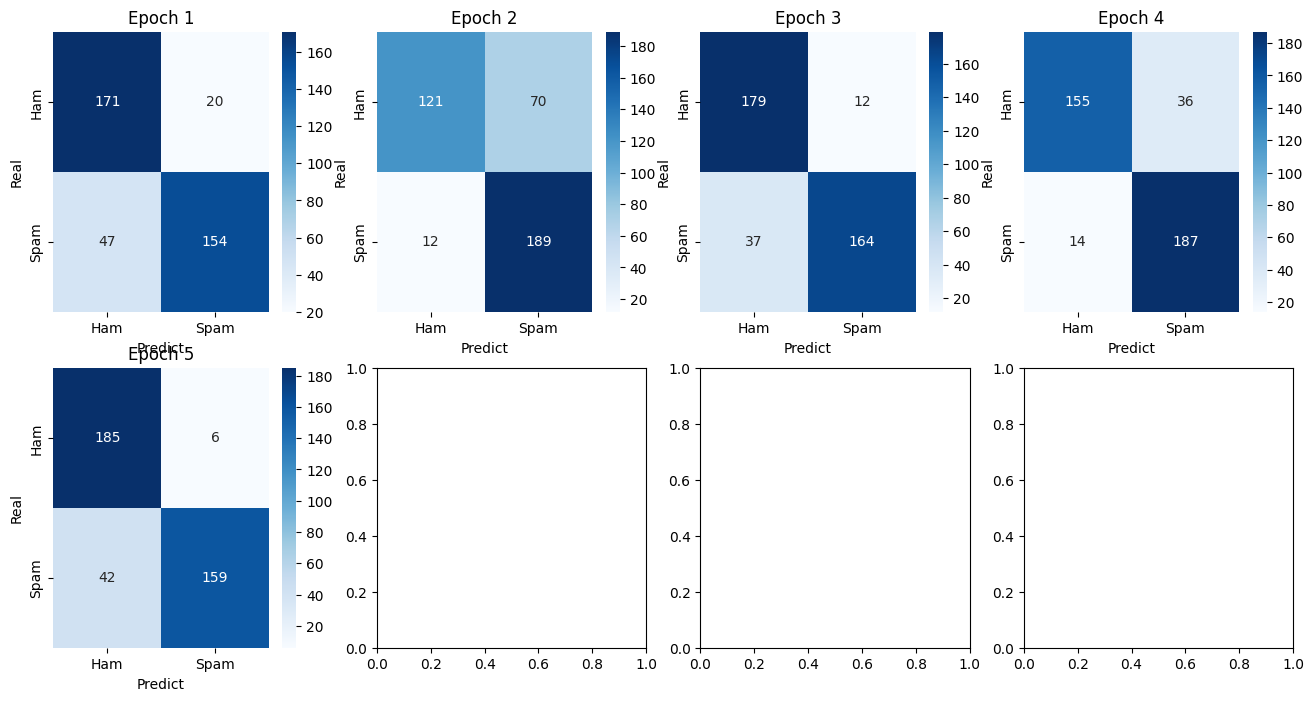

In [30]:
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
import math

epochs = 5
n_cols = 4
n_rows = math.ceil(epochs / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for epoch in range(epochs):
    # ---- Train ----
    model.train()
    total_loss = 0

    for batch_inputs, batch_labels in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        predicoes = model(batch_inputs)
        loss = criterion(predicoes, batch_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    media_loss = total_loss / len(train_loader)

    # ---- Val ----
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch_inputs, batch_labels in test_loader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)

            predicoes = model(batch_inputs)
            preds = (predicoes >= 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds)

    # MatriX Confusion
    
    cm = confusion_matrix(all_labels, all_preds)
    ax = axes[epoch]
    confusion_matrix(all_labels, all_preds)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=ax,
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam']
    )
    ax.set_title(f"Epoch {epoch+1}")
    ax.set_xlabel("Predict")
    ax.set_ylabel("Real")

    print(f"Epoch {epoch+1}/{epochs} | Loss: {media_loss:.4f} | Acc: {acc:.4f} | F1: {f1:.4f}")

In [ ]:
def predict(text):
    model.eval()
    
    tokens = tokenizer(
        [text],
        padding=True,
        truncation=True,
        max_length=64,
        return_tensors="pt"
    )
    
    input_ids = tokens['input_ids'].to(device)
    
    with torch.no_grad():
        prob = model(input_ids).item()
    
    label = "🚨 SPAM" if prob >= 0.5 else "✅ HAM"
    print(f"\n{label} (confiança: {prob:.2%})")

while True:
    text = input("\nPut the comment or 'q' for leave: ")
    if text.lower() == 'q':
        break
    predict(text)


Put the comment or 'q' for leave:  Check out my channel and subscribe for free giveaways!



🚨 SPAM (confiança: 99.82%)



Put the comment or 'q' for leave:  Great video, really enjoyed the explanation!



✅ HAM (confiança: 0.62%)



Put the comment or 'q' for leave:  FREE iPHONE! Click the link in my bio NOW!


...


🚨 SPAM (confiança: 97.36%)



Put the comment or 'q' for leave:  Can you make a video about neural networks next?



✅ HAM (confiança: 17.11%)



Put the comment or 'q' for leave:  Visit my channel for free music downloads!



🚨 SPAM (confiança: 99.62%)
